In [34]:
using Random
using Plots
using ForwardDiff
using LaTeXStrings

# Esercizio 1

## Parte a)
In statistics, we define the variance of a sample of values $x_1,\ldots,x_n$ by
$$
\sigma^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \overline{x})^2,
\qquad 
\overline{x} = \frac{1}{n} \sum_{i=1}^n x_i.
\qquad
(1.4.2)
$$
Write a function that takes as input a vector $x$ of any length and returns $\sigma^2$ as calculated by the formula. You should test your function with $x=[1,1,\ldots,1]$ and some random vectors.


In [35]:
function variance64(x::Vector{Float64})
    n = length(x)
    mean_x = sum(x) ./ n
    return sum((xi .- mean_x)^2 for xi in x) / (n .- 1)
end

function variance32(x::Vector{Float32})
    n = length(x)
    mean_x = sum(x) ./ n
    return sum((xi .- mean_x)^2 for xi in x) / (n .- 1)
end

variance32 (generic function with 1 method)

In [36]:
random_dimension = rand(5:100)
# test double precision
var_test64 = variance64([1.0, 1.0, 1.0, 1.0, 1.0])  # Should return 0.0
random_value64 = rand(Float64, random_dimension)
var_rand64 = variance64(random_value)

# test single precision
var_test32 = variance32(Float32[1, 1, 1, 1, 1])  # Should return 0.0
random_value32 = rand(Float32, random_dimension)
var_rand32 = variance32(random_value32)

# output results
println("Variance test (64-bit): ", var_test64)
println("Variance random (64-bit): ", var_rand64)
println("Variance test (32-bit): ", var_test32)
println("Variance random (32-bit): ", var_rand32)

UndefVarError: UndefVarError: `random_value` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Parte b)
One drawback of the formula (1.4.2) is that you must first compute a sum for $\overline{x}$ before performing the sum to compute $\sigma^2$. This means that we have to pass twice through the data. This is undesirable for large data sets or when the sample variance is to be computed as the data is generated. Some textbooks quote a single-loop formula:
  
$$
\begin{split}
\sigma^2 = \frac{1}{n-1} \left( u - \tfrac{1}{n}v^2 \right),\\
u  = \sum_{i=1}^n x_i^2, 
\qquad
v = \sum_{i=1}^n x_i.
\end{split}
$$

Try both formulas for the datasets below, each of which has a variance exactly equal to 1. Do this in both single and double precision.

``` julia
x = [ 1e3, 1+1e3, 2+1e3 ]
x = [ 1e6, 1+1e6, 2+1e6 ]
x = [ 1e7, 1+1e7, 2+1e7 ]
x = [ 1e8, 1+1e8, 2+1e8 ]
```

Can you explain the results?

In [37]:
function variance_single_pass64(x::Vector{Float64})
    n = length(x)
    u = sum(x.^2)
    v = sum(x)
    return (u - v^2 / n) / (n - 1)
end

function variance_single_pass32(x::Vector{Float32})
    n = length(x)
    u = sum(x.^2)
    v = sum(x)
    return (u - v^2 / n) / (n - 1)
end

variance_single_pass32 (generic function with 1 method)

In [38]:
x1 = [ 1e3, 1+1e3, 2+1e3 ]
x2 = [ 1e6, 1+1e6, 2+1e6 ]
x3 = [ 1e7, 1+1e7, 2+1e7 ]
x4 = [ 1e8, 1+1e8, 2+1e8 ]

println("=== Single Pass Variance 64 ===")
println("Variance single pass x1: ", variance_single_pass64(x1))
println("Variance single pass x2: ", variance_single_pass64(x2))
println("Variance single pass x3: ", variance_single_pass64(x3))
println("Variance single pass x4: ", variance_single_pass64(x4))

println("\n=== Two Pass Variance 64 ===")
println("Variance two pass x1: ", variance64(x1))
println("Variance two pass x2: ", variance64(x2))
println("Variance two pass x3: ", variance64(x3))
println("Variance two pass x4: ", variance64(x4))

println("\n=== Single Pass Variance 32 ===")
println("Variance single pass x1: ", variance_single_pass32(Float32.(x1)))
println("Variance single pass x2: ", variance_single_pass32(Float32.(x2)))
println("Variance single pass x3: ", variance_single_pass32(Float32.(x3)))
println("Variance single pass x4: ", variance_single_pass32(Float32.(x4)))

println("\n=== Two Pass Variance 32 ===")
println("Variance two pass x1: ", variance32(Float32.(x1)))
println("Variance two pass x2: ", variance32(Float32.(x2)))
println("Variance two pass x3: ", variance32(Float32.(x3)))
println("Variance two pass x4: ", variance32(Float32.(x4)))

=== Single Pass Variance 64 ===
Variance single pass x1: 1.0
Variance single pass x2: 1.0
Variance single pass x3: 1.0
Variance single pass x4: 0.0

=== Two Pass Variance 64 ===
Variance two pass x1: 1.0
Variance two pass x2: 1.0
Variance two pass x3: 1.0
Variance two pass x4: 1.0

=== Single Pass Variance 32 ===
Variance single pass x1: 1.0
Variance single pass x2: -131072.0
Variance single pass x3: 0.0
Variance single pass x4: 0.0

=== Two Pass Variance 32 ===
Variance two pass x1: 1.0
Variance two pass x2: 1.0
Variance two pass x3: 1.0
Variance two pass x4: 0.0

Variance single pass x2: -131072.0
Variance single pass x3: 0.0
Variance single pass x4: 0.0

=== Two Pass Variance 32 ===
Variance two pass x1: 1.0
Variance two pass x2: 1.0
Variance two pass x3: 1.0
Variance two pass x4: 0.0


## Parte c) (optional)
Instead of accumulating $\sum_i x_i$ and $\sum_i x_i^2$ we can accumulate

$$
M_k={1\over k}\sum_{i=1}^k x_i
\quad
\text{and}
\quad
Q_k=\sum_{i=1}^k (x_i-M_k)^2=
\sum_{i=1}^k x_i^2 - {1\over k}\left(\sum_{i=1}^k x_i \right)^2\,,
$$

which can be done via the updating formulas

$$
\begin{split}
M_1=x_1\,,
\qquad
M_k&=M_{k-1}+{x_k- M_{k-1}\over k}\,,
\quad
k=2,\ldots,n\,,\\[2.5mm]
Q_1=0\,,
\qquad
Q_k&=Q_{k-1}+{(k-1)(x_k-M_{k-1})^2\over k}\,,
\quad
k=2,\ldots,n\,,
\end{split}
$$

after which $\sigma^2={Q_n/ (n-1)}$.

# Esercizio 2
Let $f(x) = \frac{e^x-1}{x}$.

In [40]:
f(x) = (exp(x) - 1) / x

f (generic function with 1 method)

The relative **condition number**  $\kappa_f(x)$ for a single-variable continuous differentiable function $f\in C^1$ is defined as

$$
  \begin{split}
    \kappa_f(x) &= \lim_{\epsilon\to 0} 
    \left| { f(\tilde{x}) - f(x) \over f(x)} \times {x\over \Delta x}
    \right| \\[1.5ex]
    &= \lim_{\epsilon\to 0}  \left| \dfrac{ f(x+\epsilon x) - f(x) }{ \epsilon x} \cdot  {x\over f(x)}  \right|\\[1.5ex]
    &= \left| { x\over f(x)}  f'(x)  \right|.
  \end{split}
$$

In [41]:
function kappa_f(x, func::Function)
    return abs(x * ForwardDiff.derivative(func, x) / func(x))
end

kappa_f (generic function with 1 method)

## Parte a)
Find the condition number $\kappa_f(x)$. What is the maximum of $\kappa_f(x)$ over the interval $-1\le x \le 1$?

=== Condition Number Analysis ===
Maximum condition number for naive algorithm: 0.5819767068693265


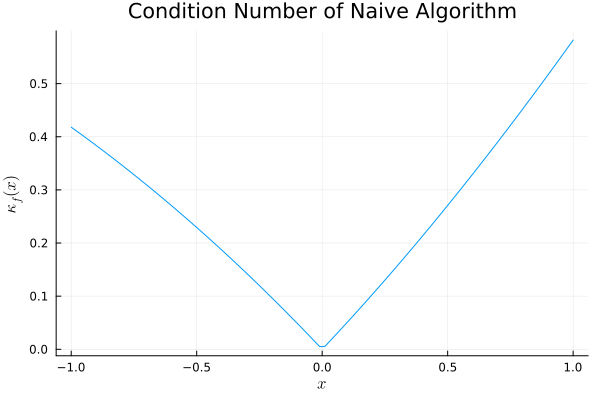

In [42]:
x_vals = LinRange(-1, 1, 100)
kappa_naive = kappa_f.(x_vals, f)
max_kappa_naive = maximum(kappa_naive)

# Condition number
println("=== Condition Number Analysis ===")
println("Maximum condition number for naive algorithm: ", max_kappa_naive)

# Plot condition number
plot(x_vals, kappa_naive, title="Condition Number of Naive Algorithm", xlabel=L"x", ylabel=L"\kappa_f(x)", legend=false)

## Parte b)
Use the naive algorithm

``` julia
f(x)= (exp(x)-1)/x
```
to compute $f(x)$ at $x=10^{-3},10^{-4},10^{-5},\ldots,10^{-16}$.

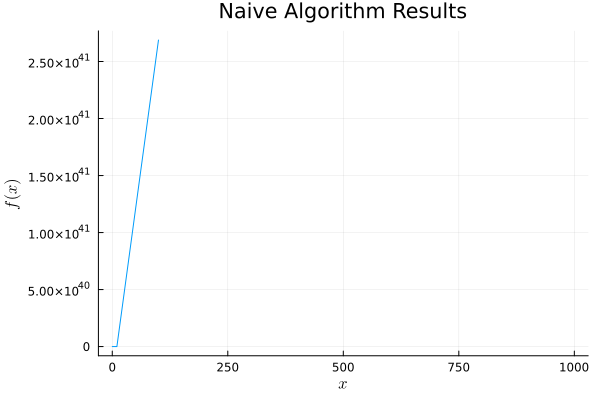

In [43]:
x_values = [10.0^-i for i in -3:16]
f_values = f.(x_values)

# Plot naive algorithm results
plot(x_values, f_values, title="Naive Algorithm Results", xlabel=L"x", ylabel=L"f(x)", legend=false)

## Parte c)
Create a second algorithm from the first $n$ terms of the Maclaurin series, i.e.,

$$
p(x) = 1 + \frac{1}{2!}x + \frac{1}{3!}x^2 + \cdots + \frac{1}{(n+1)!}x^n.
$$

Evaluate it at the same values of $x$ as in part (b). To do this you have to choose a value for $n$. Check for the stability of the result when varying $n$. Could you have guessed a good value of $n$ from the start? 

In [44]:
function mclaurin_series(x, n::Int)
    sum = zero(x)
    for k in 0:n
        sum += x^k / factorial(k + 1)
    end
    return sum
end

mclaurin_series (generic function with 1 method)

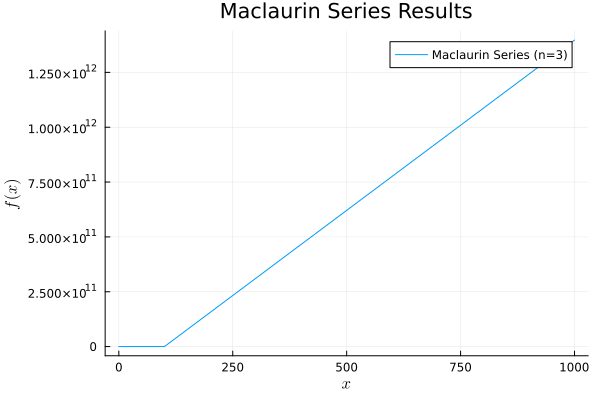

In [45]:
n = 5 # number of terms in the series
f_mclaurin_values = [mclaurin_series(x, n) for x in x_values]
plot(x_values, f_mclaurin_values, title="Maclaurin Series Results", xlabel=L"x", ylabel=L"f(x)", label="Maclaurin Series (n=3)", legend=:topright)

In [46]:
kappa_mclaurin = kappa_f.(x_vals, mclaurin_series)
# max_kappa_mclaurin = maximum(kappa_mclaurin)

# println("=== Condition Number Analysis for Maclaurin Series ===")
# println("Maximum condition number for Maclaurin series: ", max_kappa_mclaurin)

# plot(x_vals, kappa_mclaurin, title="Condition Number of Maclaurin Series", xlabel=L"x", ylabel=L"\kappa_f(x)", legend=false)

MethodError: MethodError: no method matching mclaurin_series(::ForwardDiff.Dual{ForwardDiff.Tag{typeof(mclaurin_series), Float64}, Float64, 1})
The function `mclaurin_series` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  mclaurin_series(::Any, !Matched::Int64)
   @ Main ~/Code/University/Fisica-Computazionale/20251008/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X25sZmlsZQ==.jl:1


## Parte d)
Compare the results from the two implementations as a function of $x$. Which algorithm do you think is more accurate, and why?

## Parte e) (opzionale)
Write a third algorithm that computes:

$$
g(x)= {y-1\over \log(y)}
\quad
\text{where}
\quad
y=e^x\,.
$$

Evaluate it at the same values of $x$ as in part (b). How does this compare with the other two in terms of accuracy?